In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, ttest_1samp, wilcoxon
from itertools import combinations
from matplotlib.patches import Patch

from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parents[2]))
from config import FIGURES_OUT, DATA_DIR

path = str(DATA_DIR / 'supp_figures' / 'supp_fig_15_posture_code') + '/'
save_figures = str(FIGURES_OUT / 'supp_figures' / 'supp_fig_15_posture_code') + '/'
suffix = 'outcome'

In [3]:
def add_sig_bar(x1, x2, y, p, ax, bar_height=0.02, text_offset=0.01):
    ax.plot([x1, x1, x2, x2], [y, y + bar_height, y + bar_height, y], color='black', linewidth=1)
    if p < 0.001: text = '***'
    elif p < 0.01: text = '**'
    elif p < 0.05: text = '*'
    else: text = 'n.s.'
    ax.text((x1 + x2) / 2, y + bar_height + text_offset, text, ha='center', va='bottom', fontsize=9)

## Delay decoder — decoding accuracy across early / mid / late delay

early_delay vs mid_delay: t=5.235, p=0.0000, n=106
early_delay vs late_delay: t=6.835, p=0.0000, n=106
mid_delay vs late_delay: t=-0.002, p=0.9987, n=106


C:\Users\tiffany.ona\AppData\Local\Temp\ipykernel_22512\1969220471.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


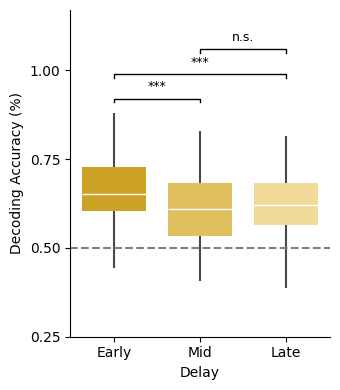

In [5]:
agg_df = pd.read_csv(path + 'decoding_results_delay_decoder.csv')

if not agg_df.empty:
    epoch_order = ['early_delay', 'mid_delay', 'late_delay']
    x_map = {k: i for i, k in enumerate(epoch_order)}

    df_plot = agg_df.copy()
    df_plot['x'] = df_plot['epoch'].map(x_map)
    rng = np.random.default_rng(0)
    session_jitter = {s: rng.uniform(-0.15, 0.15) for s in df_plot['session'].unique()}
    df_plot['x_jitter'] = df_plot['x'] + df_plot['session'].map(session_jitter)

    fig, ax = plt.subplots(1, 1, figsize=(3.5, 4))
    sns.boxplot(
        x='epoch', y='accuracy', data=df_plot,
        order=epoch_order, showfliers=False,
        palette=["#E6AF0B", "#F6CA48", "#FFE28C"],
        width=0.75,
        medianprops=dict(color='white', linewidth=1),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=0),
        boxprops=dict(edgecolor='none')
    )

    ymax = df_plot['accuracy'].max()
    height_step = 0.07
    current_height = ymax + 0.03

    for (e1, e2) in combinations(epoch_order, 2):
        d1 = df_plot[df_plot['epoch'] == e1].set_index('session')['accuracy']
        d2 = df_plot[df_plot['epoch'] == e2].set_index('session')['accuracy']
        common_sessions = d1.index.intersection(d2.index)
        if len(common_sessions) > 1:
            stat, p = ttest_rel(d1.loc[common_sessions], d2.loc[common_sessions])
            print(f"{e1} vs {e2}: t={stat:.3f}, p={p:.4f}, n={len(common_sessions)}")
            add_sig_bar(x_map[e1], x_map[e2], current_height, p, ax, bar_height=0.01, text_offset=0.015)
            current_height += height_step

    ax.set_ylabel("Decoding Accuracy (%)")
    ax.set_xlabel("Delay")
    ax.set_xticks(range(len(epoch_order)), ['Early', 'Mid', 'Late'])
    ax.set_ylim(0.25, current_height + 0.05)
    ax.axhline(0.5, color='grey', linestyle='--')
    ax.set_yticks(np.arange(0.25, 1.1, 0.25))
    sns.despine()
    plt.tight_layout()
    # plt.savefig(save_figures + '/decoding_accuracy_aggregated.svg', dpi=300)
    plt.show()

## Outcome decoder — accuracy per mouse (baseline only), hued by epoch

In [6]:
agg_df = pd.read_csv(path + 'decoding_results_outcome_epoch.csv')

C:\Users\tiffany.ona\AppData\Local\Temp\ipykernel_22512\3573059794.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


Mouse E04 — start vs delay: t=-4.133, p=0.0025, n=10
Mouse E11 — start vs delay: t=-4.450, p=0.0001, n=33
Mouse E13 — start vs delay: t=-6.602, p=0.0000, n=20
Mouse E17 — start vs delay: t=-12.386, p=0.0000, n=17
Mouse E19 — start vs delay: t=-2.297, p=0.0473, n=10
Mouse E20 — start vs delay: t=-4.839, p=0.0001, n=23
Mouse E22 — start vs delay: t=-3.553, p=0.0052, n=11


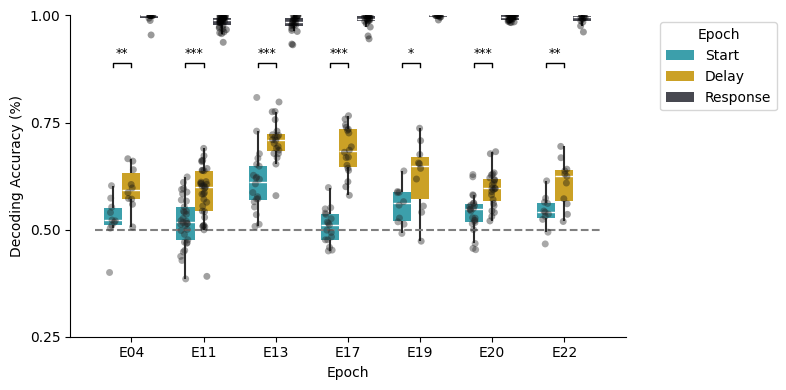

In [7]:
epoch_order = ['start', 'delay', 'response']
x_map = {k: i for i, k in enumerate(epoch_order)}
epoch_colors = {'start': "#29ADBE", 'delay': "#E6AF0B", 'response': "#464751"}

df_plot = agg_df.loc[agg_df['type'] == 'baseline'].copy()
df_plot['x'] = df_plot['epoch'].map(x_map)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.boxplot(
    x='mouse', y='accuracy', hue='epoch', data=df_plot,
    hue_order=epoch_order, showfliers=False, palette=epoch_colors,
    width=0.75,
    medianprops=dict(color='white', linewidth=1),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=0),
    boxprops=dict(edgecolor='none')
)
sns.stripplot(
    x='mouse', y='accuracy', hue='epoch', data=df_plot,
    hue_order=epoch_order, dodge=True, jitter=0.15,
    color='black', alpha=0.4, size=5, ax=ax, zorder=3
)

hue_offsets = {'start': -0.25, 'delay': 0.00, 'response': 0.25}
bar_height = 0.88
for i, mouse in enumerate(sorted(df_plot['mouse'].unique())):
    df_mouse = df_plot[df_plot['mouse'] == mouse]
    d_start = df_mouse[df_mouse['epoch'] == 'start'].set_index('session')['accuracy']
    d_delay = df_mouse[df_mouse['epoch'] == 'delay'].set_index('session')['accuracy']
    common = d_start.index.intersection(d_delay.index)
    if len(common) > 1:
        stat, p = ttest_rel(d_start.loc[common], d_delay.loc[common])
        print(f"Mouse {mouse} — start vs delay: t={stat:.3f}, p={p:.4f}, n={len(common)}")
        add_sig_bar(i + hue_offsets['start'], i + hue_offsets['delay'], bar_height, p, ax, bar_height=0.01, text_offset=0.005)

ax.set_ylabel("Decoding Accuracy (%)")
ax.set_xlabel("Epoch")
ax.set_ylim(0.25, 1)
ax.hlines(0.5, -0.5, 6.5, colors='grey', linestyles='dashed')
ax.set_yticks(np.arange(0.25, 1.1, 0.25))
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Start', 'Delay', 'Response'], title='Epoch', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.savefig(save_figures + 'decoding_accuracy_per_mouse.svg', dpi=300)
plt.show()

## Outcome decoder — per session, paired t-test

start: baseline=0.542, test=0.574, p=0.0011, n=124
delay: baseline=0.627, test=0.550, p=0.0000, n=125
response: baseline=0.988, test=0.938, p=0.0000, n=125


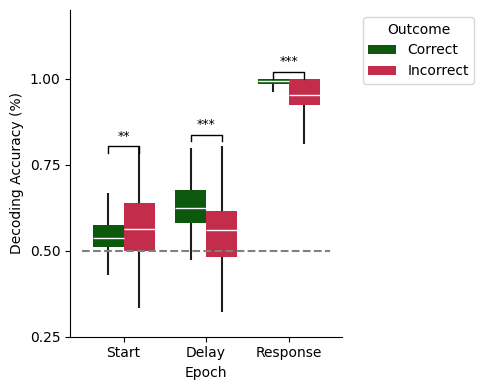

In [8]:
epoch_order = ['start', 'delay', 'response']
x_map = {k: i for i, k in enumerate(epoch_order)}
box_width = 0.75
hue_offsets = {'baseline': -box_width / 4, 'test': box_width / 4}

df_plot = agg_df.copy()

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.boxplot(
    x='epoch', y='accuracy', hue='type', data=df_plot,
    order=epoch_order,
    palette={'baseline': 'darkgreen', 'test': 'crimson'},
    showfliers=False, width=box_width,
    medianprops=dict(color='white', linewidth=1),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=0),
    boxprops=dict(edgecolor='none')
)

for epoch in epoch_order:
    d_base = df_plot[(df_plot['epoch'] == epoch) & (df_plot['type'] == 'baseline')].set_index('session')['accuracy']
    d_test = df_plot[(df_plot['epoch'] == epoch) & (df_plot['type'] == 'test')].set_index('session')['accuracy']
    common = d_base.index.intersection(d_test.index)
    if len(common) < 2: continue
    stat, p = ttest_rel(d_base.loc[common], d_test.loc[common], nan_policy='omit')
    print(f"{epoch}: baseline={d_base.loc[common].mean():.3f}, test={d_test.loc[common].mean():.3f}, p={p:.4f}, n={len(common)}")
    x_center = x_map[epoch]
    y = df_plot[df_plot['epoch'] == epoch]['accuracy'].quantile(0.95) + 0.08
    if y > 1.0: y = 1.0
    add_sig_bar(x_center + hue_offsets['baseline'], x_center + hue_offsets['test'], y, p, ax)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Correct', 'Incorrect'], title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylabel("Decoding Accuracy (%)")
ax.set_xlabel("Epoch")
ax.set_ylim(0.25, 1.2)
ax.set_yticks(np.arange(0.25, 1.1, 0.25))
ax.hlines(0.5, -0.5, 2.5, colors='grey', linestyles='dashed')
plt.xticks(rotation=0, ticks=range(3), labels=['Start', 'Delay', 'Response'])
sns.despine()
plt.tight_layout()
plt.savefig(save_figures + 'decoding_accuracy_outcome_epoch_session.svg', dpi=300)
plt.show()

## Feature coefs — load data

In [9]:
coefs_grouped = pd.read_csv(path + 'decoder_coefficients_grouped.csv')

if 'feature' not in coefs_grouped.columns:
    coefs_melted = coefs_grouped.melt(
        id_vars=['mouse', 'session', 'epoch'],
        var_name='feature', value_name='mean_weight'
    )
else:
    coefs_melted = coefs_grouped.copy()

coefs_melted['mean_weight'] = coefs_melted['mean_weight'].abs()

start — paw vs mouth: t=3.043, p=0.0029, n=124
delay — paw vs mouth: t=6.049, p=0.0000, n=125
response — paw vs mouth: t=-7.412, p=0.0000, n=125


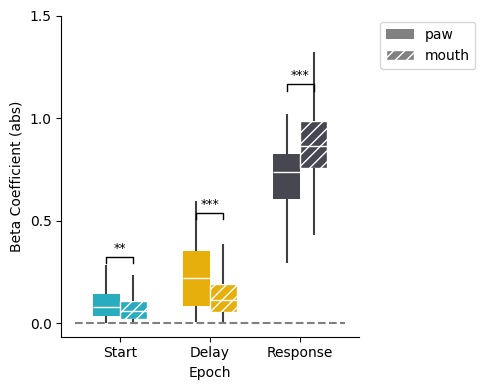

In [10]:
epoch_colors = {'start': "#29ADBE", 'delay': "#E6AF0B", 'response': "#464751"}
epoch_order = ['start', 'delay', 'response']
x_map = {k: i for i, k in enumerate(epoch_order)}
hue_offsets = {'paw': -0.6 / 4, 'mouth': 0.6 / 4}

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    x='epoch', y='mean_weight', hue='feature',
    data=coefs_melted, order=epoch_order, hue_order=['paw', 'mouth'],
    showfliers=False, width=0.6, gap=0,
    medianprops=dict(color='white', linewidth=1),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=0),
    boxprops=dict(edgecolor='none'),
    ax=ax
)

n_epochs = 3
boxes = [patch for patch in ax.patches if type(patch).__name__ == 'PathPatch']
for i, patch in enumerate(boxes):
    is_mouth = i >= n_epochs
    epoch = epoch_order[i % n_epochs]
    patch.set_facecolor(epoch_colors[epoch])
    if is_mouth:
        patch.set_hatch('///')
        patch.set_edgecolor('white')
    else:
        patch.set_edgecolor('none')

for epoch in epoch_order:
    d_paw = coefs_melted[(coefs_melted['epoch'] == epoch) & (coefs_melted['feature'] == 'paw')].set_index('session')['mean_weight']
    d_mouth = coefs_melted[(coefs_melted['epoch'] == epoch) & (coefs_melted['feature'] == 'mouth')].set_index('session')['mean_weight']
    common = d_paw.index.intersection(d_mouth.index)
    if len(common) < 2: continue
    stat, p = ttest_rel(d_paw.loc[common], d_mouth.loc[common])
    print(f"{epoch} — paw vs mouth: t={stat:.3f}, p={p:.4f}, n={len(common)}")
    x_center = x_map[epoch]
    y = coefs_melted[coefs_melted['epoch'] == epoch]['mean_weight'].quantile(0.95) + 0.05
    add_sig_bar(x_center + hue_offsets['paw'], x_center + hue_offsets['mouth'], y, p, ax, bar_height=0.03, text_offset=0.01)

legend_elements = [
    Patch(facecolor='grey', label='paw'),
    Patch(facecolor='grey', hatch='///', edgecolor='white', label='mouth'),
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.hlines(0, -0.5, 2.5, colors='grey', linestyles='dashed')
plt.xticks(rotation=0, ticks=range(3), labels=['Start', 'Delay', 'Response'])
plt.yticks(np.arange(0, 1.6, 0.5))
plt.xlabel('Epoch')
plt.ylabel('Beta Coefficient (abs)')
plt.tight_layout()
sns.despine()
plt.savefig(save_figures + '/decoder_coefficients_grouped_body_parts.svg', dpi=300)
plt.show()

## Cross-decoder — load data

In [11]:
results_df = pd.read_csv(path + 'decoding_results_cross_epoch.csv')

### heatmap averaged across mice

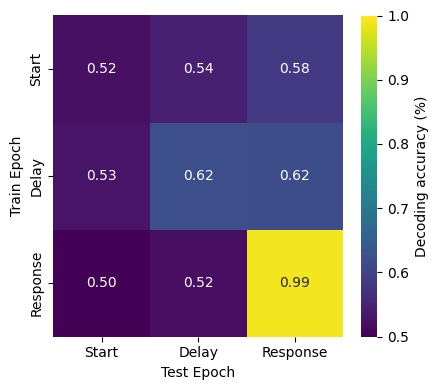

In [12]:
mask = (
    ((results_df['train_epoch'] == results_df['test_epoch']) & (results_df['type'] == 'baseline')) |
    ((results_df['train_epoch'] != results_df['test_epoch']) & (results_df['type'] == 'test'))
)
results_filtered = results_df.loc[mask]

accuracy_matrix = results_filtered.pivot_table(
    index='train_epoch', columns='test_epoch', values='accuracy'
)

epoch_order = ['start', 'delay', 'response']
accuracy_matrix = accuracy_matrix.loc[epoch_order, epoch_order]
label_map = {'start': 'Start', 'delay': 'Delay', 'response': 'Response'}
accuracy_matrix.index = accuracy_matrix.index.map(label_map)
accuracy_matrix.columns = accuracy_matrix.columns.map(label_map)

plt.figure(figsize=(4.5, 4))
sns.heatmap(
    accuracy_matrix, annot=True, fmt=".2f", cmap="viridis",
    cbar_kws={'label': 'Decoding accuracy (%)'},
    vmin=0.5, vmax=1.0
)
plt.xlabel("Test Epoch")
plt.ylabel("Train Epoch")
plt.tight_layout()
plt.savefig(save_figures + '/cross_epoch_heatmap.svg', dpi=300, bbox_inches='tight')
plt.show()

### Response→Start/Delay/Response, one-sample t-test vs chance

response_to_start: t=0.692, p=0.4900, n=135
response_to_delay: t=3.067, p=0.0026, n=135
response_to_response: t=409.495, p=0.0000, n=135


C:\Users\tiffany.ona\AppData\Local\Temp\ipykernel_22512\3384204613.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


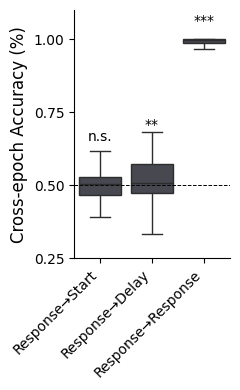

In [13]:
keep = ['response_to_response', 'response_to_delay', 'response_to_start']
plot = results_df[results_df['epoch'].isin(keep)].copy()
plot['type'] = np.where(plot['epoch'] == 'response_to_delay', 'delay', plot['type'])
plot['type'] = np.where(plot['epoch'] == 'response_to_start', 'start', plot['type'])
plot = plot.groupby(['session', 'epoch', 'type'])['accuracy'].mean().reset_index()

epoch_order = ['response_to_start', 'response_to_delay', 'response_to_response']
x_map = {k: i for i, k in enumerate(epoch_order)}
epoch_colors = {'start': "#464751", 'delay': "#464751", 'baseline': "#464751"}

def add_sig_marker(x, y, p, ax, text_offset=0.02):
    if p < 0.001: text = '***'
    elif p < 0.01: text = '**'
    elif p < 0.05: text = '*'
    else: text = 'n.s.'
    ax.text(x, y + text_offset, text, ha='center', va='bottom', fontsize=10)

fig, ax = plt.subplots(figsize=(2.5, 4))
sns.boxplot(
    data=plot, x='epoch', y='accuracy', hue='type',
    showfliers=False, legend=False, palette=epoch_colors,
    order=epoch_order, ax=ax
)

for epoch in epoch_order:
    vals = plot[plot['epoch'] == epoch].groupby('session')['accuracy'].mean().dropna()
    if len(vals) < 2: continue
    stat, p = ttest_1samp(vals, popmean=0.5)
    print(f"{epoch}: t={stat:.3f}, p={p:.4f}, n={len(vals)}")
    x = x_map[epoch]
    y = plot[plot['epoch'] == epoch]['accuracy'].quantile(0.95) + 0.02
    add_sig_marker(x, y, p, ax)

plt.xlabel('')
plt.ylabel('Cross-epoch Accuracy (%)', fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=['Response→Start', 'Response→Delay', 'Response→Response'], rotation=45, ha='right')
plt.ylim(0.25, 1.1)
plt.yticks([0.25, 0.5, 0.75, 1])
sns.despine()
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.7)
plt.legend().remove()
plt.tight_layout()
plt.show()